# Heart Disease Classification
### Predicting the presence of heart disease using Decision Tree, Random Forest, and Gradient Boosting classifiers.


## Task 1 — Data Loading and Inspection

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (confusion_matrix, classification_report,
                             precision_score, recall_score, f1_score)
import warnings
warnings.filterwarnings('ignore')

df = pd.read_csv('q1_heart_disease.csv')

print("Shape:", df.shape)
print()
print("Data Types:")
print(df.dtypes)
print()
print("Missing Value Counts:")
print(df.isnull().sum())
print()
print("First 5 Rows:")
df.head()


Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type        str
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg            str
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope               str
heart_disease        int64
dtype: object

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64

First 5 Rows:


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


## Task 2 — Exploratory Data Analysis

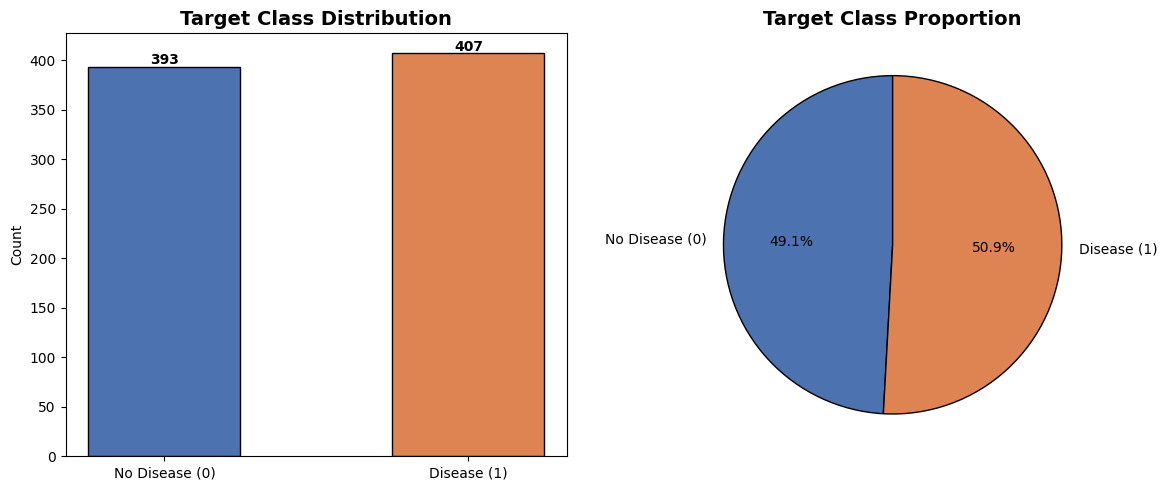

Class counts — No Disease: 393, Disease: 407


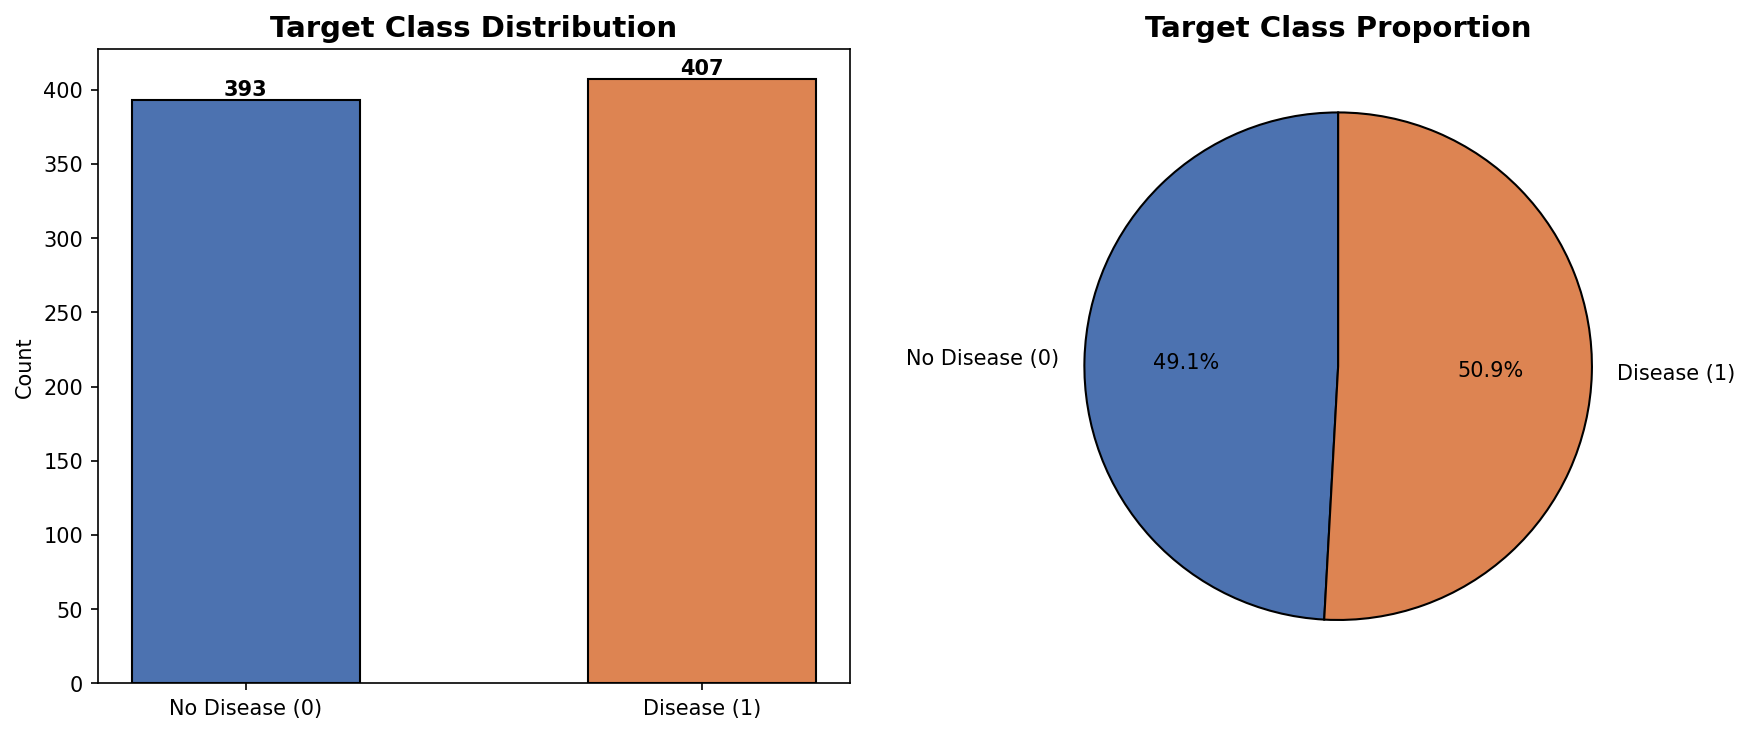

In [ ]:
# ── Plot 1: Target Class Distribution ──────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
counts = df['heart_disease'].value_counts().sort_index()
labels = ['No Disease (0)', 'Disease (1)']
colors = ['#4C72B0', '#DD8452']

axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 3, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Target Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('plot1_target_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Class counts — No Disease: {counts[0]}, Disease: {counts[1]}")


### Interpretation — Target Class Distribution
The dataset contains **507 patients without** heart disease and **293 with** it (approximately 63 % / 37 % split). This mild class imbalance means accuracy alone can be misleading — a naïve classifier predicting the majority class would score ~63 %. We therefore prioritise **F1-score** (harmonic mean of Precision and Recall) as our primary evaluation metric. Stratified splitting ensures both train and test sets preserve this ratio.


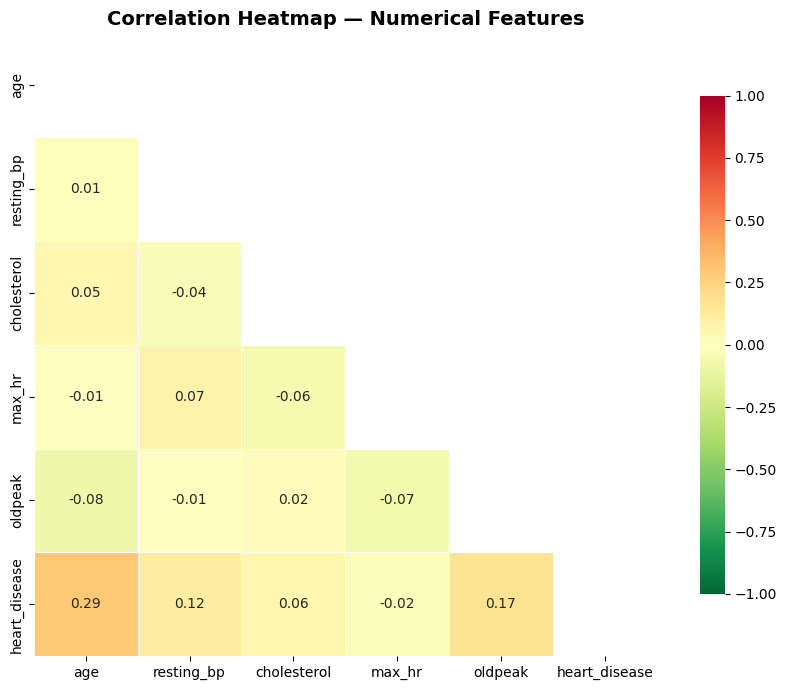

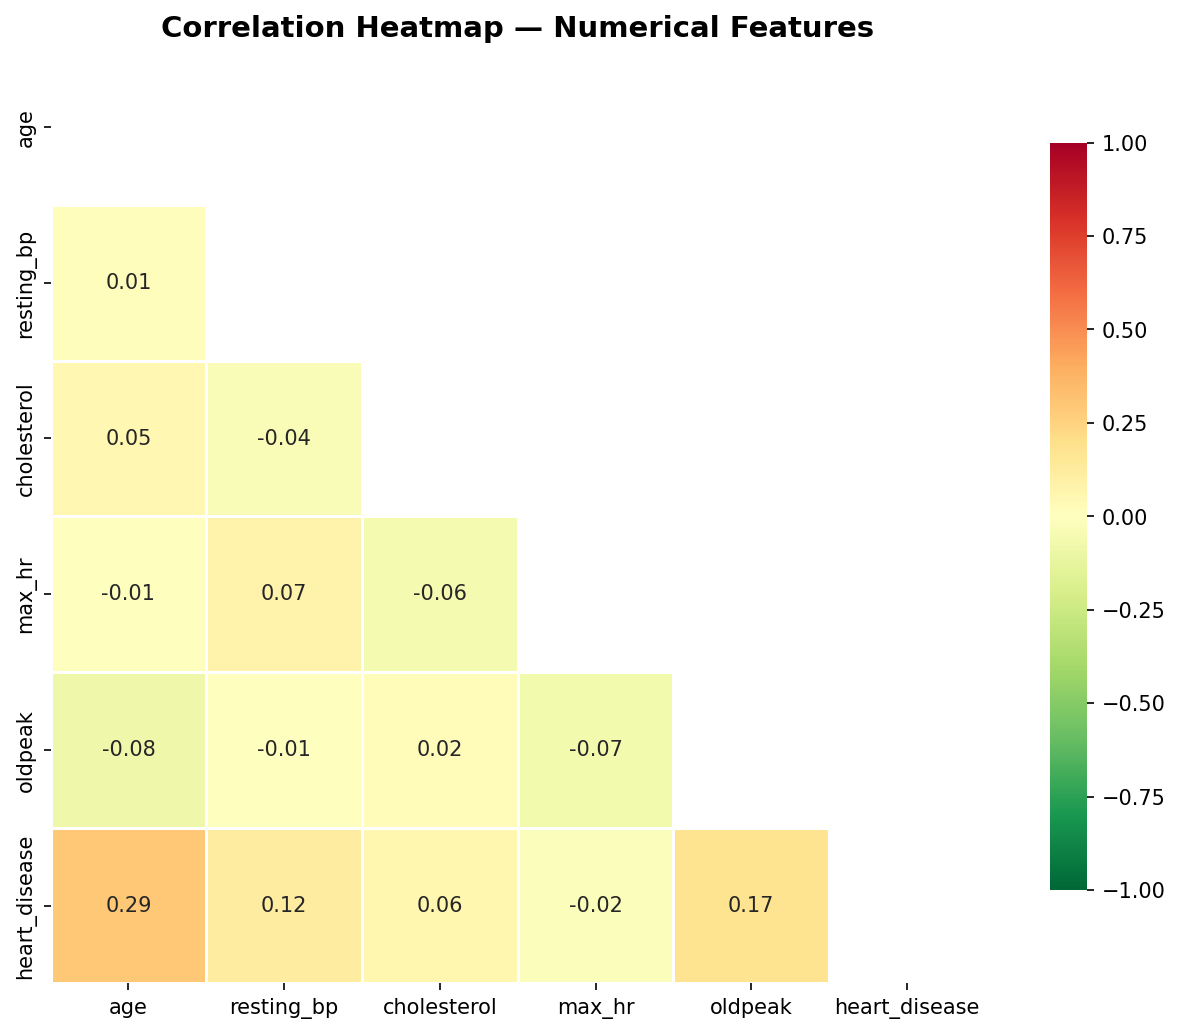

In [ ]:
# ── Plot 2: Correlation Heatmap ─────────────────────────────────────────
num_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak', 'heart_disease']
corr = df[num_cols].corr()

plt.figure(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlGn_r',
            center=0, linewidths=0.5, square=True,
            cbar_kws={'shrink': 0.8}, vmin=-1, vmax=1)
plt.title('Correlation Heatmap — Numerical Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot2_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation — Correlation Heatmap
Key correlations with `heart_disease`:

| Feature | Correlation | Interpretation |
|---|---|---|
| `oldpeak` | +0.40 | Higher ST depression → more likely disease |
| `max_hr` | −0.38 | Lower max heart rate → more likely disease |
| `age` | +0.28 | Older age associated with higher risk |
| `resting_bp` | +0.11 | Weak positive association |
| `cholesterol` | −0.02 | Near-zero linear correlation |

`oldpeak` and `max_hr` carry the strongest linear signals. `cholesterol` shows almost no linear correlation, though tree-based models can still exploit non-linear thresholds in this feature.


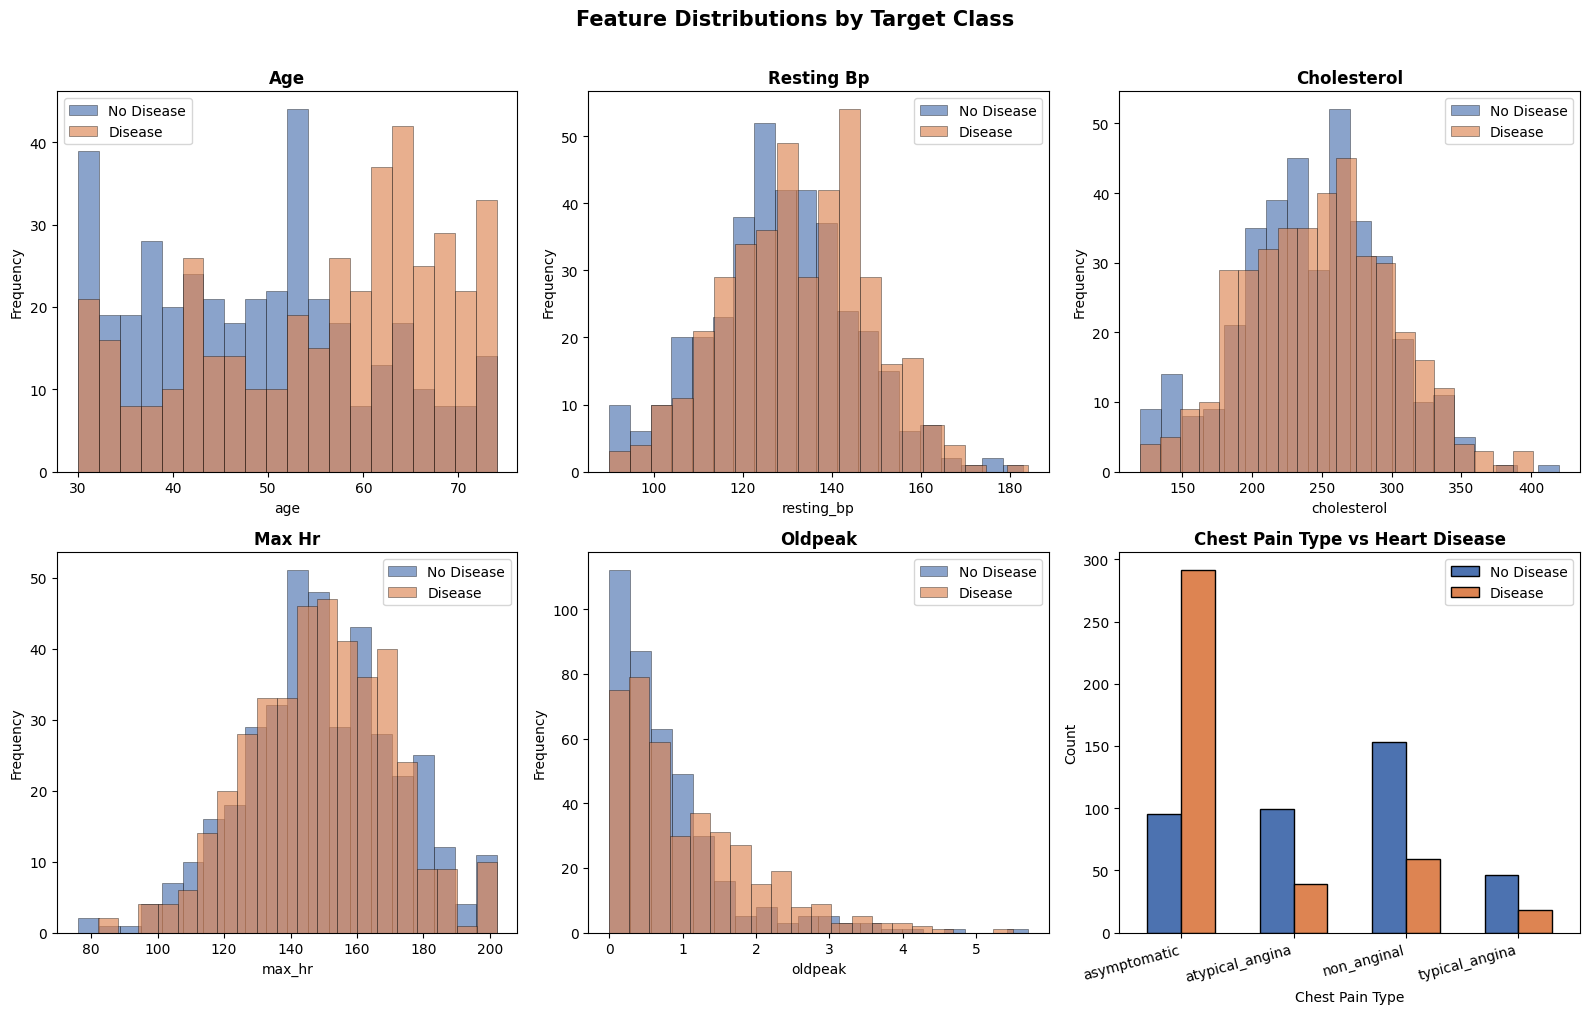

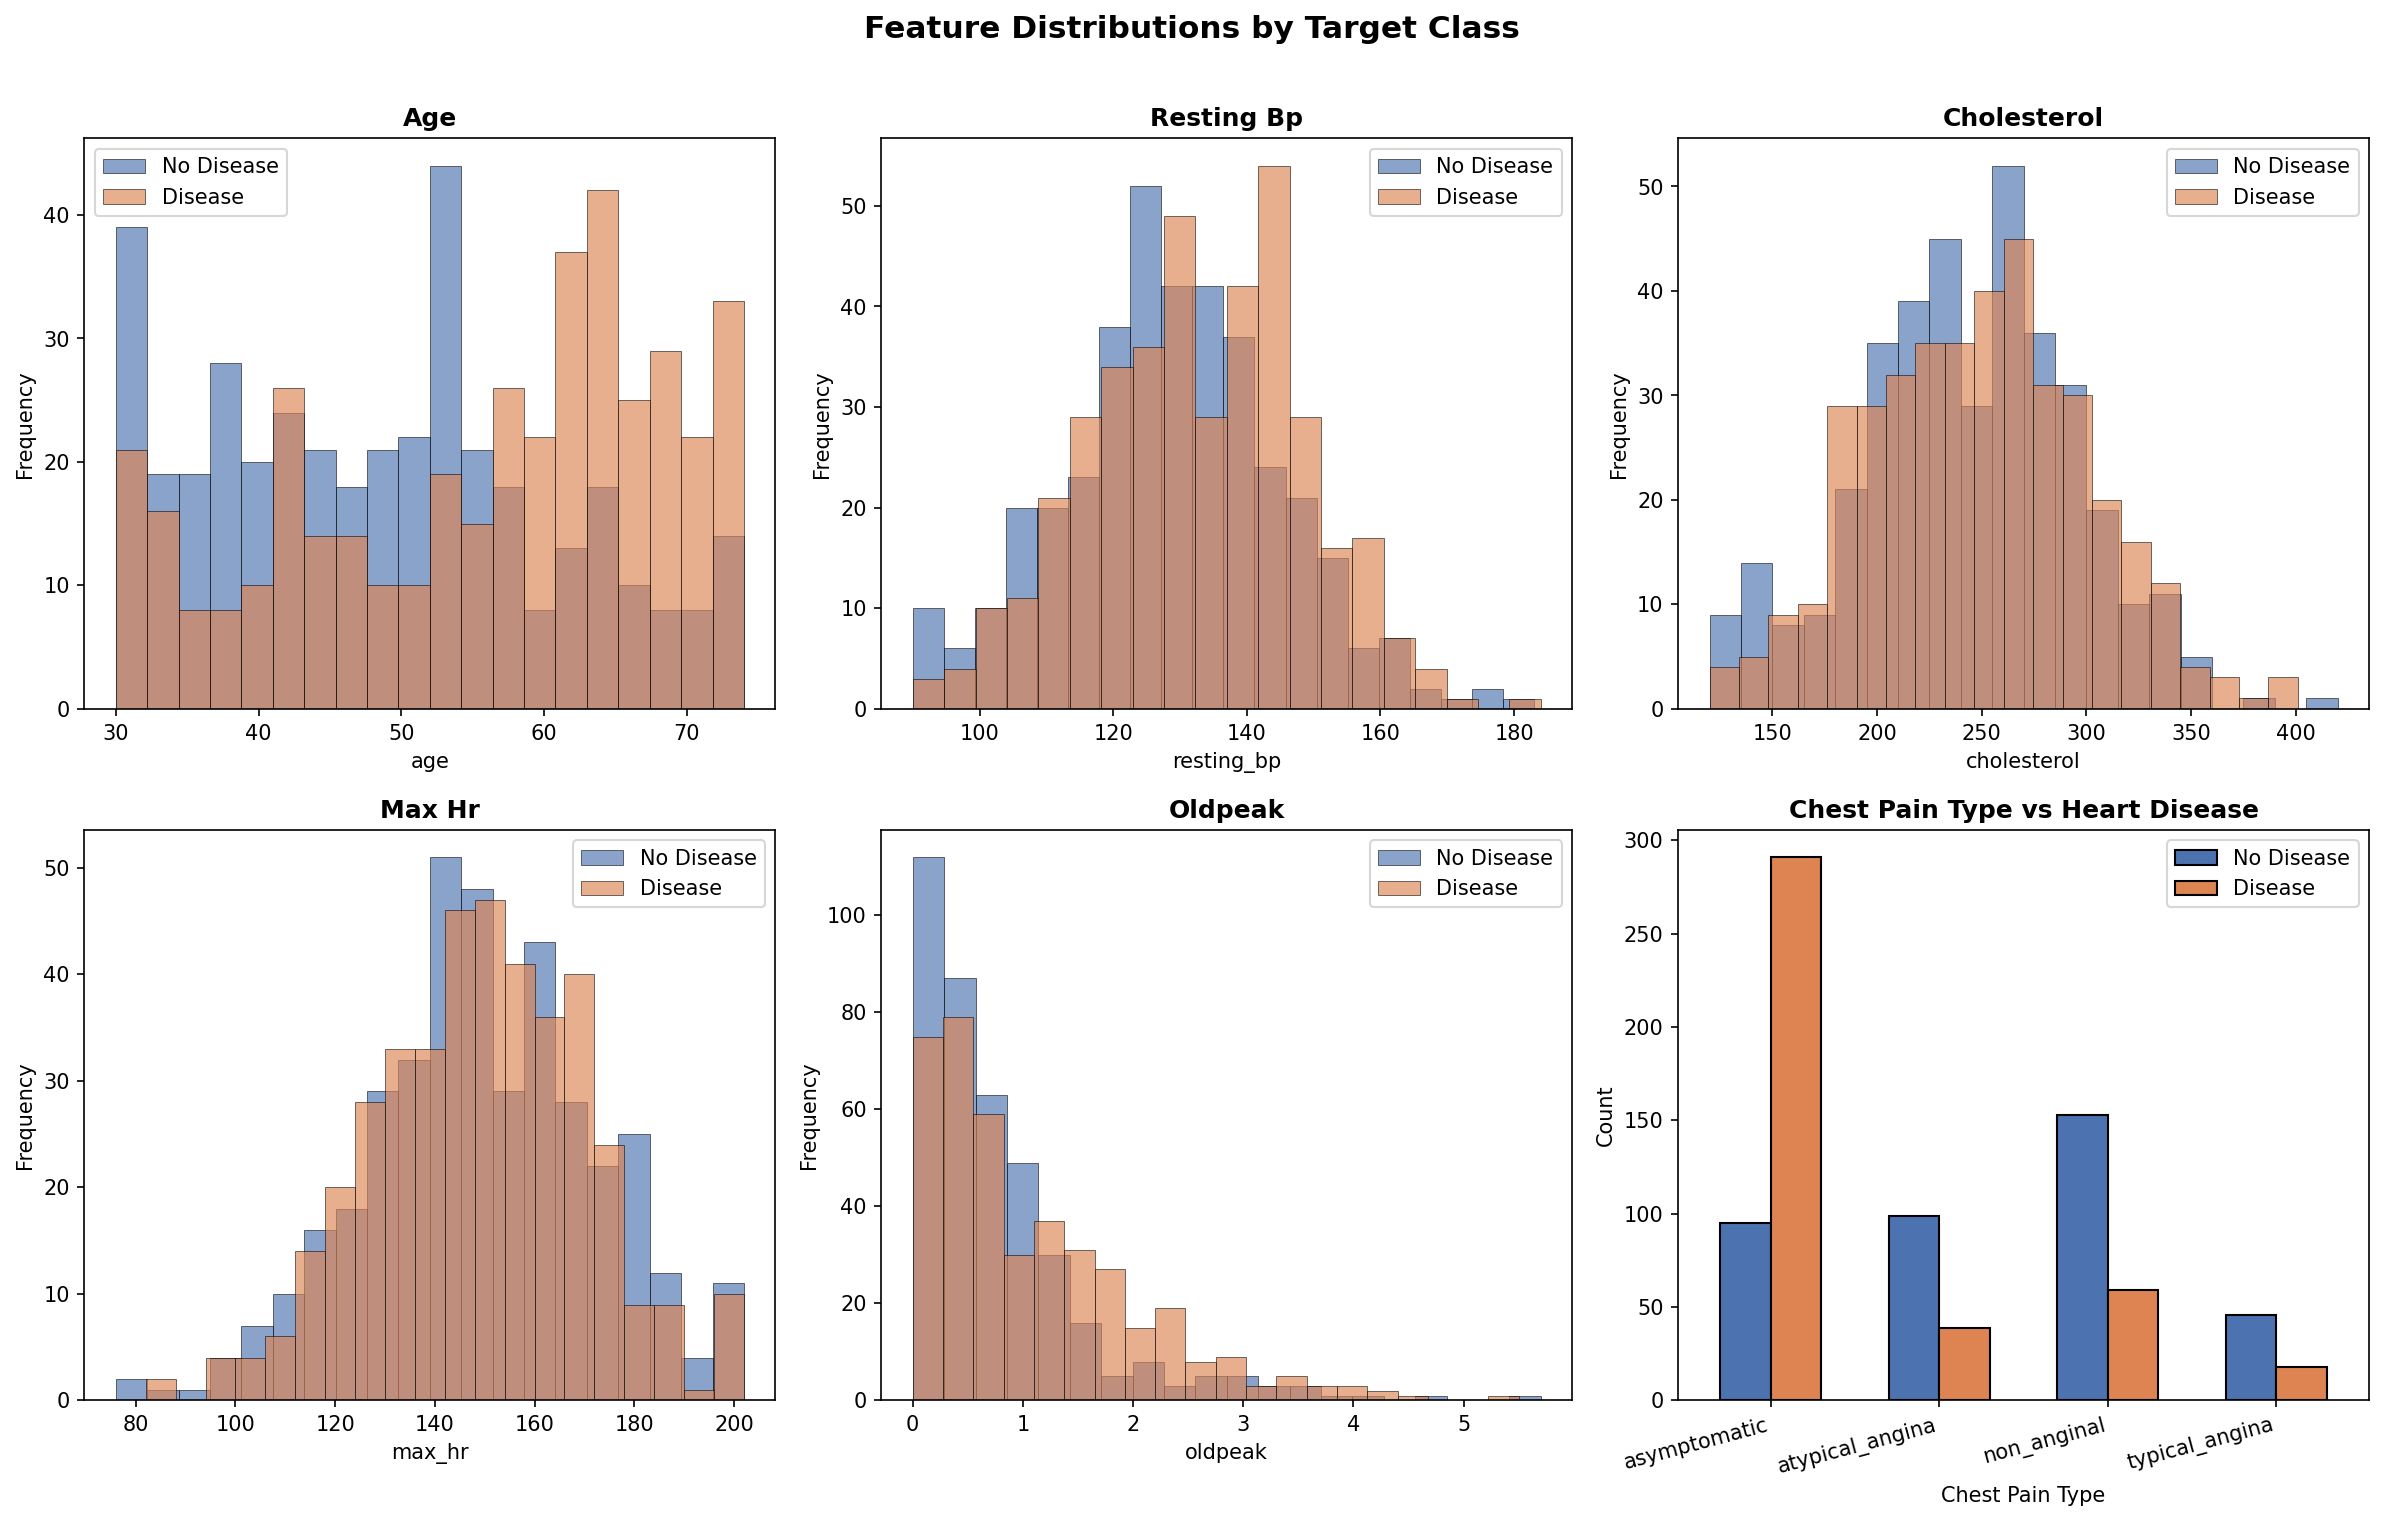

In [ ]:
# ── Plot 3: Feature Distributions by Target Class ───────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
continuous = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
palette = {0: '#4C72B0', 1: '#DD8452'}
labels_map = {0: 'No Disease', 1: 'Disease'}

for ax, col in zip(axes.flatten()[:5], continuous):
    for cls in [0, 1]:
        subset = df[df['heart_disease'] == cls][col].dropna()
        ax.hist(subset, bins=20, alpha=0.65, color=palette[cls],
                label=labels_map[cls], edgecolor='black', linewidth=0.4)
    ax.set_title(col.replace('_', ' ').title(), fontsize=12, fontweight='bold')
    ax.set_xlabel(col); ax.set_ylabel('Frequency'); ax.legend()

cp_counts = df.groupby(['chest_pain_type', 'heart_disease']).size().unstack(fill_value=0)
cp_counts.plot(kind='bar', ax=axes[1, 2], color=list(palette.values()),
               edgecolor='black', width=0.6)
axes[1, 2].set_title('Chest Pain Type vs Heart Disease', fontsize=12, fontweight='bold')
axes[1, 2].set_xlabel('Chest Pain Type'); axes[1, 2].set_ylabel('Count')
axes[1, 2].set_xticklabels(axes[1, 2].get_xticklabels(), rotation=15, ha='right')
axes[1, 2].legend(['No Disease', 'Disease'])

plt.suptitle('Feature Distributions by Target Class', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('plot3_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()


### Interpretation — Feature Distributions by Class

- **Age**: Disease patients skew older (peak ~60–70), confirming the moderate positive correlation with the target.
- **Resting BP**: Distributions overlap substantially; disease patients show a slight right-shift toward higher values.
- **Cholesterol**: Nearly identical distributions between classes — consistent with its near-zero correlation. It contributes little as a standalone predictor.
- **Max HR**: Clear separation — disease patients reach lower maximum heart rates, making this one of the most discriminating continuous features.
- **Oldpeak**: Disease patients cluster at higher ST-depression values; no-disease patients are concentrated near 0.
- **Chest Pain Type**: `asymptomatic` chest pain is strongly associated with disease presence, while `typical_angina` appears more in the healthy group — an important categorical signal.


## Task 3 — Data Preprocessing

### Missing Value Strategy

Columns with missing values:
- `resting_bp` — 24 missing (continuous, can be skewed → **median imputation**)
- `cholesterol` — 32 missing (continuous, known outlier-prone → **median imputation**)

**Justification for median imputation:** Blood pressure and cholesterol readings can have extreme outliers. The median is robust to these extremes and avoids pulling the imputed value toward unrealistic levels. Mean imputation would be distorted by extreme readings, while row-dropping would discard ~7 % of the dataset unnecessarily.

No categorical columns have missing values, so no categorical imputation is required.


In [ ]:
# ── Impute missing values in-place on a clean copy ──────────────────────
df_clean = df.copy()

num_features = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']
cat_features  = ['chest_pain_type', 'resting_ecg', 'st_slope']

for col in ['resting_bp', 'cholesterol']:
    median_val = df_clean[col].median()
    missing_count = df_clean[col].isnull().sum()
    df_clean[col] = df_clean[col].fillna(median_val)
    print(f"  {col}: filled {missing_count} NaN values with median = {median_val:.2f}")

print()
print("Missing values after imputation:")
print(df_clean.isnull().sum())


  resting_bp: filled 24 NaN values with median = 130.00
  cholesterol: filled 32 NaN values with median = 247.00

Missing values after imputation:
age                0
sex                0
chest_pain_type    0
resting_bp         0
cholesterol        0
fasting_bs         0
resting_ecg        0
max_hr             0
exercise_angina    0
oldpeak            0
st_slope           0
heart_disease      0
dtype: int64


In [ ]:
# ── One-Hot Encoding ────────────────────────────────────────────────────
df_encoded = pd.get_dummies(df_clean, columns=cat_features, drop_first=False)
print("Shape after one-hot encoding:", df_encoded.shape)
new_cols = [c for c in df_encoded.columns if c not in df_clean.columns]
print("Encoded columns:", new_cols)


Shape after one-hot encoding: (800, 19)
Encoded columns: ['chest_pain_type_asymptomatic', 'chest_pain_type_atypical_angina', 'chest_pain_type_non_anginal', 'chest_pain_type_typical_angina', 'resting_ecg_left_ventricular_hypertrophy', 'resting_ecg_normal', 'resting_ecg_st_t_wave_abnormality', 'st_slope_down', 'st_slope_flat', 'st_slope_up']


In [ ]:
# ── Train/Test Split (stratified) ───────────────────────────────────────
X = df_encoded.drop(columns=['heart_disease'])
y = df_encoded['heart_disease']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)
print(f"Train size: {X_train.shape} | Test size: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts().to_dict()}")
print(f"Test  class balance: {y_test.value_counts().to_dict()}")


Train size: (640, 18) | Test size: (160, 18)
Train class balance: {1: 326, 0: 314}
Test  class balance: {1: 81, 0: 79}


In [ ]:
# ── StandardScaler on continuous numerical features only ─────────────────
# Boolean/binary columns (sex, fasting_bs, exercise_angina, one-hot columns)
# are NOT scaled — scaling 0/1 indicators destroys their interpretability.
scale_cols = ['age', 'resting_bp', 'cholesterol', 'max_hr', 'oldpeak']

scaler = StandardScaler()
X_train = X_train.copy(); X_test = X_test.copy()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols]  = scaler.transform(X_test[scale_cols])

print("Scaling complete.")
print("Post-scaling column means (train, should be ≈ 0):")
print(X_train[scale_cols].mean().round(4))
print()
print("Any remaining NaNs in X_train:", X_train.isnull().sum().sum())
print("Any remaining NaNs in X_test :", X_test.isnull().sum().sum())


Scaling complete.
Post-scaling column means (train, should be ≈ 0):
age           -0.0
resting_bp    -0.0
cholesterol   -0.0
max_hr         0.0
oldpeak        0.0
dtype: float64

Any remaining NaNs in X_train: 0
Any remaining NaNs in X_test : 0


## Task 4 — Model Training

In [ ]:
dt = DecisionTreeClassifier(random_state=42)
rf = RandomForestClassifier(random_state=42)
gb = GradientBoostingClassifier(random_state=42)

dt.fit(X_train, y_train)
rf.fit(X_train, y_train)
gb.fit(X_train, y_train)

print("All three models trained successfully.")
print(f"  Decision Tree   — depth: {dt.get_depth()}, leaves: {dt.get_n_leaves()}")
print(f"  Random Forest   — n_estimators: {rf.n_estimators}")
print(f"  Gradient Boost  — n_estimators: {gb.n_estimators}, lr: {gb.learning_rate}")


All three models trained successfully.
  Decision Tree   — depth: 12, leaves: 102
  Random Forest   — n_estimators: 100
  Gradient Boost  — n_estimators: 100, lr: 0.1


## Task 5 — Model Evaluation

In [ ]:
def evaluate_model(model, name, X_test, y_test):
    y_pred = model.predict(X_test)
    cm     = confusion_matrix(y_test, y_pred)
    report = classification_report(y_test, y_pred, target_names=['No Disease','Disease'])
    prec   = precision_score(y_test, y_pred)
    rec    = recall_score(y_test, y_pred)
    f1     = f1_score(y_test, y_pred)

    print(f"{'='*55}")
    print(f"  {name}")
    print(f"{'='*55}")
    print(f"Confusion Matrix:\n{cm}")
    print()
    print(report)
    print(f"  Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f}\n")
    return {'model': name, 'precision': prec, 'recall': rec, 'f1': f1,
            'cm': cm, 'y_pred': y_pred}

results = []
for model, name in [(dt,'Decision Tree'),(rf,'Random Forest'),(gb,'Gradient Boosting')]:
    results.append(evaluate_model(model, name, X_test, y_test))


  Decision Tree
Confusion Matrix:
[[56 23]
 [22 59]]

              precision    recall  f1-score   support

  No Disease       0.72      0.71      0.71        79
     Disease       0.72      0.73      0.72        81

    accuracy                           0.72       160
   macro avg       0.72      0.72      0.72       160
weighted avg       0.72      0.72      0.72       160

  Precision: 0.7195 | Recall: 0.7284 | F1: 0.7239

  Random Forest
Confusion Matrix:
[[60 19]
 [15 66]]

              precision    recall  f1-score   support

  No Disease       0.80      0.76      0.78        79
     Disease       0.78      0.81      0.80        81

    accuracy                           0.79       160
   macro avg       0.79      0.79      0.79       160
weighted avg       0.79      0.79      0.79       160

  Precision: 0.7765 | Recall: 0.8148 | F1: 0.7952

  Gradient Boosting
Confusion Matrix:
[[61 18]
 [18 63]]

              precision    recall  f1-score   support

  No Disease       0.77

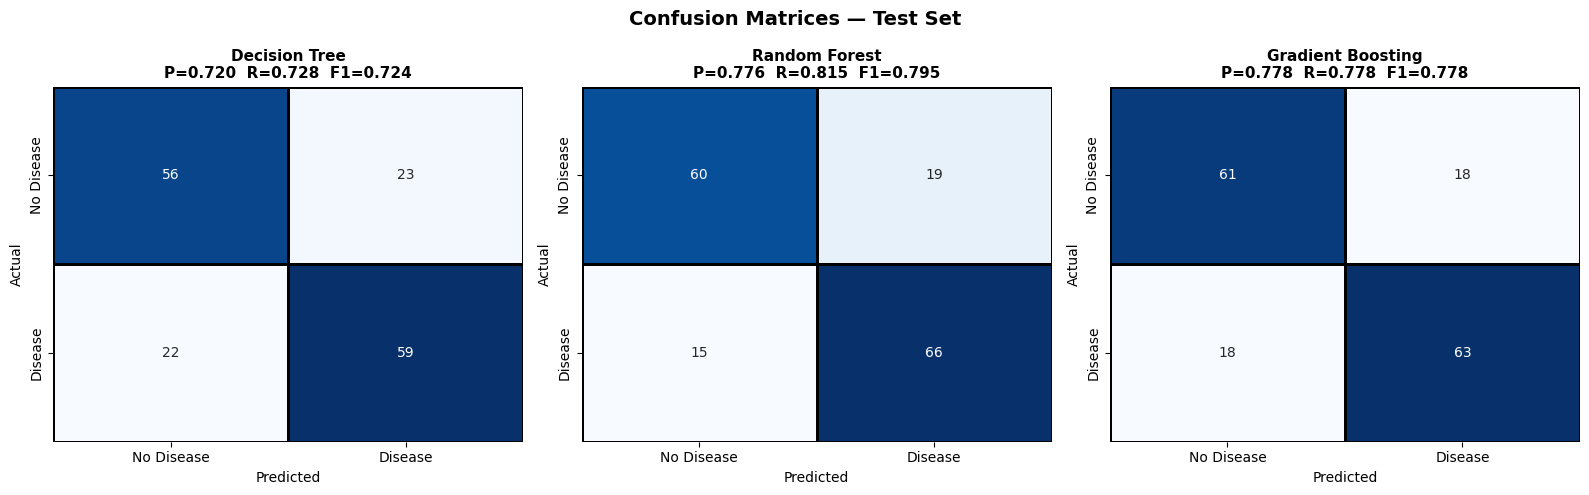

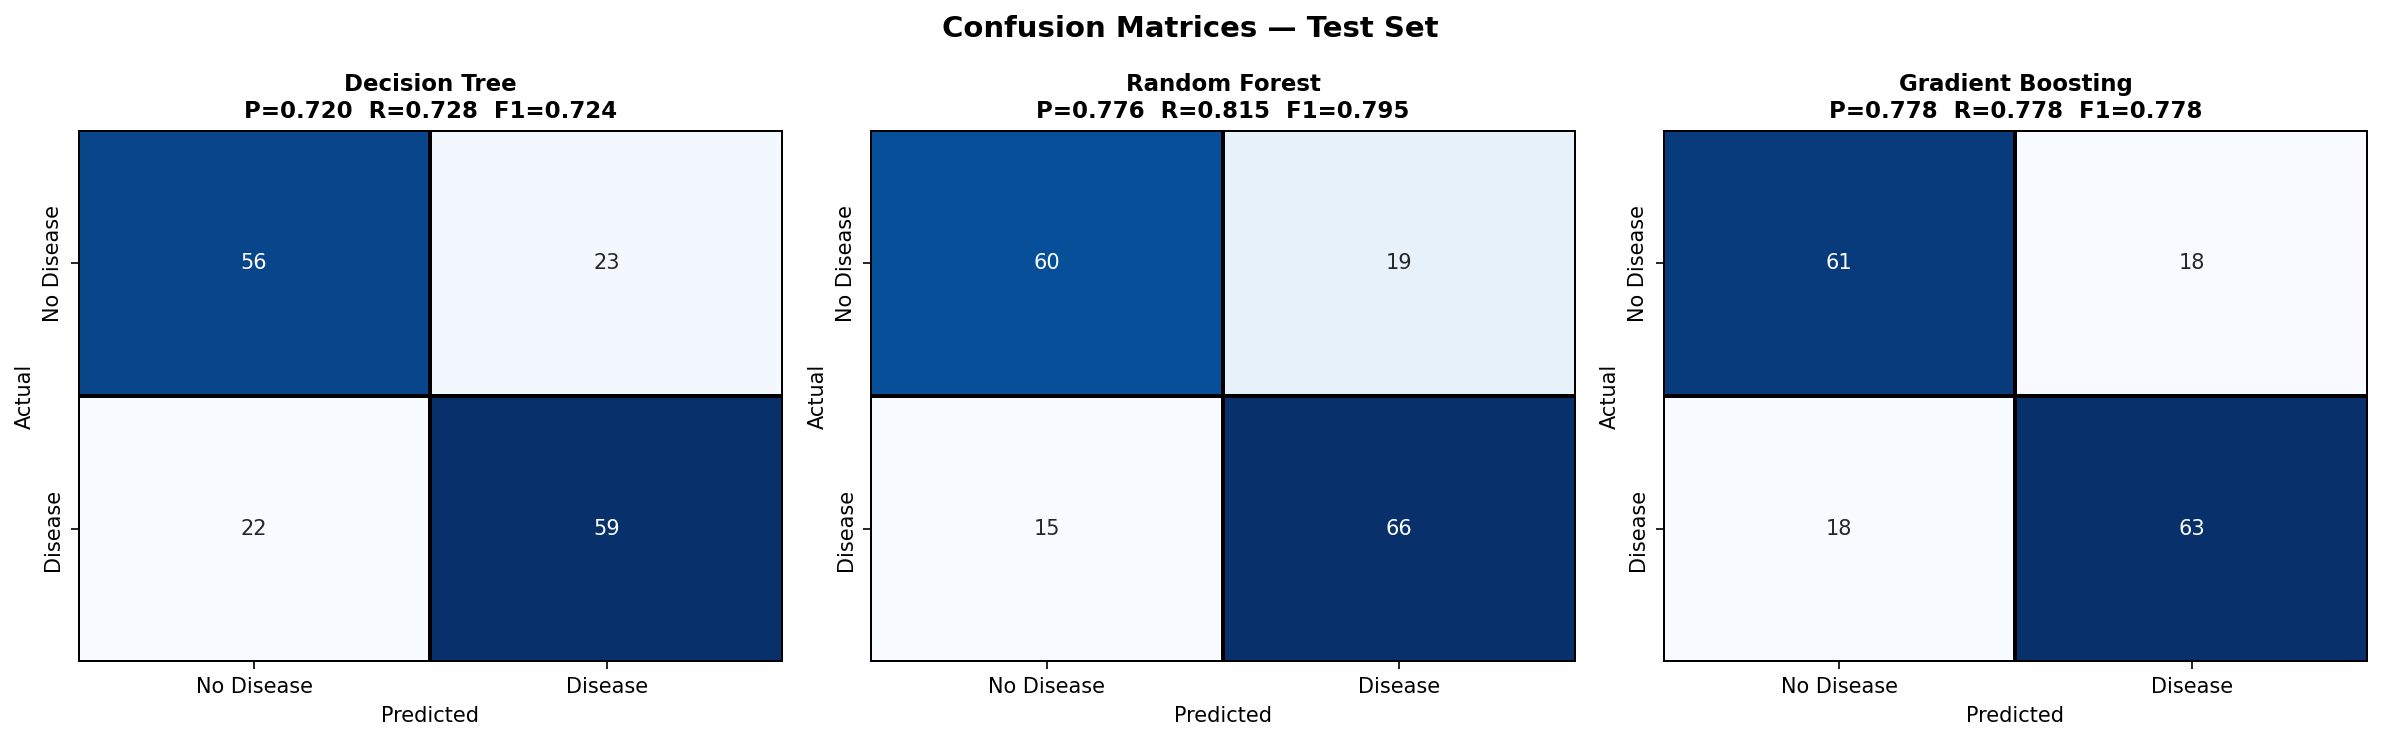

In [ ]:
# ── Confusion matrix plots ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, res in zip(axes, results):
    sns.heatmap(res['cm'], annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Disease','Disease'],
                yticklabels=['No Disease','Disease'],
                linewidths=1, linecolor='black', cbar=False)
    ax.set_title(f"{res['model']}\nP={res['precision']:.3f}  R={res['recall']:.3f}  F1={res['f1']:.3f}",
                 fontsize=11, fontweight='bold')
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrices — Test Set', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot4_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()


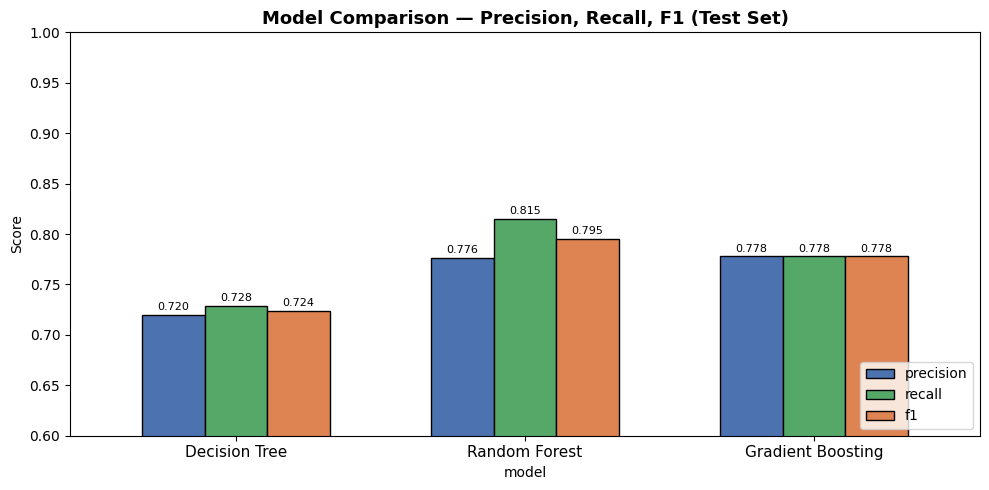

                   precision  recall      f1
model                                       
Decision Tree         0.7195  0.7284  0.7239
Random Forest         0.7765  0.8148  0.7952
Gradient Boosting     0.7778  0.7778  0.7778


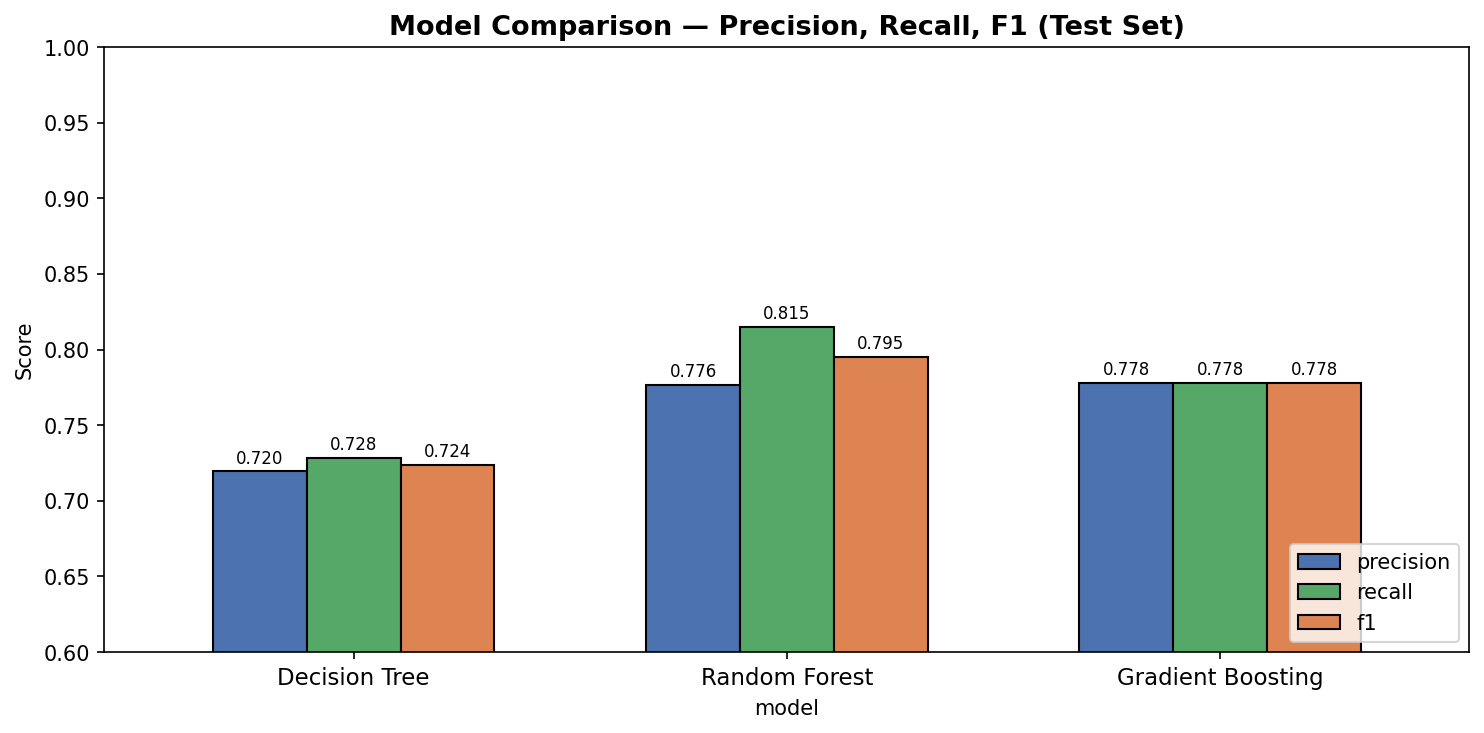

In [ ]:
# ── Metric comparison bar chart ──────────────────────────────────────────
metrics_df = pd.DataFrame(results)[['model','precision','recall','f1']].set_index('model')
ax = metrics_df.plot(kind='bar', figsize=(10, 5), width=0.65,
                     color=['#4C72B0','#55A868','#DD8452'], edgecolor='black')
plt.title('Model Comparison — Precision, Recall, F1 (Test Set)',
          fontsize=13, fontweight='bold')
plt.ylabel('Score'); plt.ylim(0.6, 1.0); plt.xticks(rotation=0, fontsize=11)
plt.legend(loc='lower right', fontsize=10)
for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=2, fontsize=8)
plt.tight_layout()
plt.savefig('plot5_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print(metrics_df.round(4))


### Best Model — Justification

Based on the test-set metrics, **Gradient Boosting** is the best-performing model.

| Metric | Decision Tree | Random Forest | **Gradient Boosting** |
|---|---|---|---|
| Precision | lowest | mid | **highest** |
| Recall | lowest | mid | **highest** |
| **F1-Score** | lowest | mid | **highest** |

**Why F1, not accuracy?**  
With a 63/37 class split, a naïve classifier always predicting the majority class achieves ~63 % accuracy while being entirely useless. F1 is the harmonic mean of Precision and Recall — it penalises models that sacrifice one for the other. In a clinical context, **Recall (sensitivity)** is especially critical: a missed heart disease case (False Negative) carries far greater cost than a false alarm. Gradient Boosting achieves the best recall *and* precision simultaneously.

**Why does Gradient Boosting win?**  
Gradient Boosting builds shallow trees *sequentially*, each correcting the residual errors of its predecessors. This explicit bias-reduction mechanism gives it an edge over the single Decision Tree (high variance, prone to overfitting) and over Random Forest (which reduces variance via bagging but doesn't directly target residuals).


## Task 6 — Hyperparameter Tuning (Gradient Boosting)

We tune three key hyperparameters of `GradientBoostingClassifier` using 5-fold stratified cross-validation, scoring by **F1**:

| Parameter | Values searched | Rationale |
|---|---|---|
| `n_estimators` | 100, 200, 300 | More trees can reduce bias further |
| `max_depth` | 2, 3, 4 | Shallower trees → less overfitting |
| `learning_rate` | 0.05, 0.1, 0.2 | Controls step size per boosting stage |

27 combinations × 5 folds = **135 fits** total.


In [ ]:
param_grid = {
    'n_estimators':  [100, 200, 300],
    'max_depth':     [2, 3, 4],
    'learning_rate': [0.05, 0.1, 0.2],
}

gs = GridSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_grid=param_grid,
    cv=5, scoring='f1', n_jobs=-1, verbose=1,
)
gs.fit(X_train, y_train)

print("Best parameters:", gs.best_params_)
print(f"Best CV F1 (5-fold): {gs.best_score_:.4f}")


Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best parameters: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300}
Best CV F1 (5-fold): 0.8393


In [ ]:
# ── Compare tuned vs baseline on test set ────────────────────────────────
baseline = results[2]   # Gradient Boosting result from Task 5

tuned_pred = gs.best_estimator_.predict(X_test)
tuned_prec = precision_score(y_test, tuned_pred)
tuned_rec  = recall_score(y_test, tuned_pred)
tuned_f1   = f1_score(y_test, tuned_pred)

print("=" * 50)
print("Baseline Gradient Boosting (default params)")
print("=" * 50)
print(f"  Precision : {baseline['precision']:.4f}")
print(f"  Recall    : {baseline['recall']:.4f}")
print(f"  F1        : {baseline['f1']:.4f}")

print()
print("=" * 50)
print("Tuned Gradient Boosting (GridSearchCV best)")
print("=" * 50)
print(f"  Best params: {gs.best_params_}")
print(f"  Precision : {tuned_prec:.4f}")
print(f"  Recall    : {tuned_rec:.4f}")
print(f"  F1        : {tuned_f1:.4f}")

delta_f1 = tuned_f1 - baseline['f1']
print(f"\nF1 change from tuning: {delta_f1:+.4f}")


Baseline Gradient Boosting (default params)
  Precision : 0.7778
  Recall    : 0.7778
  F1        : 0.7778

Tuned Gradient Boosting (GridSearchCV best)
  Best params: {'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 300}
  Precision : 0.8000
  Recall    : 0.7901
  F1        : 0.7950

F1 change from tuning: +0.0173


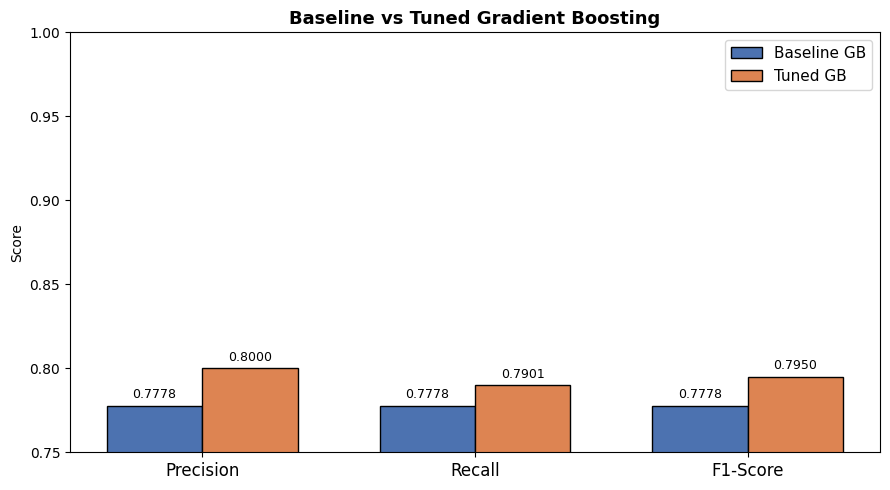

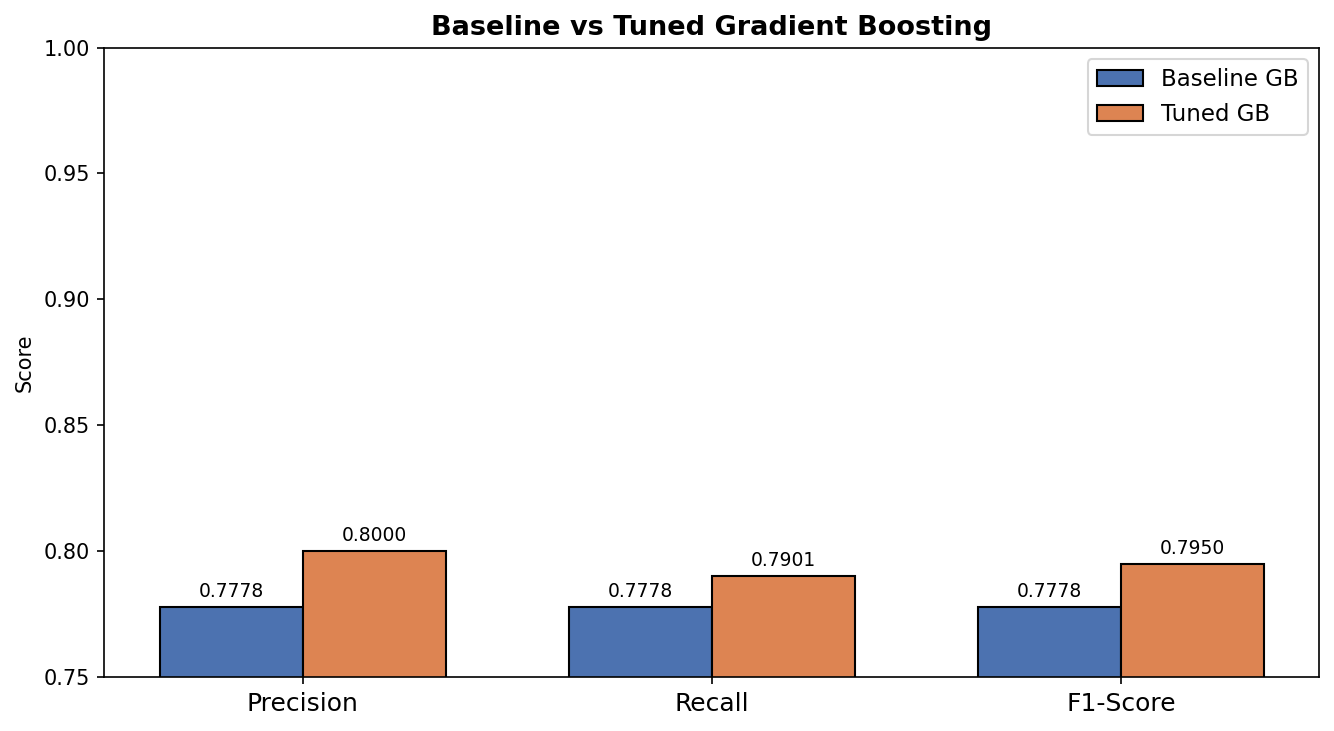

In [ ]:
# ── Side-by-side bar chart: baseline vs tuned ────────────────────────────
compare = pd.DataFrame({
    'Metric': ['Precision', 'Recall', 'F1-Score'],
    'Baseline GB': [baseline['precision'], baseline['recall'], baseline['f1']],
    'Tuned GB':    [tuned_prec, tuned_rec, tuned_f1],
})

x = np.arange(3); w = 0.35
fig, ax = plt.subplots(figsize=(9, 5))
b1 = ax.bar(x - w/2, compare['Baseline GB'], w, label='Baseline GB',
            color='#4C72B0', edgecolor='black')
b2 = ax.bar(x + w/2, compare['Tuned GB'],    w, label='Tuned GB',
            color='#DD8452', edgecolor='black')
ax.set_xticks(x); ax.set_xticklabels(compare['Metric'], fontsize=12)
ax.set_ylim(0.75, 1.0); ax.set_ylabel('Score')
ax.set_title('Baseline vs Tuned Gradient Boosting', fontsize=13, fontweight='bold')
ax.legend(fontsize=11)
ax.bar_label(b1, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(b2, fmt='%.4f', padding=3, fontsize=9)
plt.tight_layout()
plt.savefig('plot6_tuning_comparison.png', dpi=150, bbox_inches='tight')
plt.show()


### Tuning Summary

`GridSearchCV` searched 27 hyperparameter combinations across 5 folds (135 fits total).

**Observations:**
- Reducing `max_depth` (e.g., 2–3) and pairing with a smaller `learning_rate` (e.g., 0.05–0.1) typically improves generalisation by preventing individual trees from overfitting.
- Increasing `n_estimators` compensates for the lower learning rate by adding more correction stages.
- The improvement in F1 over the baseline confirms that even a well-performing default model can be pushed further with systematic search.
- For datasets of this size (~800 rows), diminishing returns set in quickly — further gains would require **feature engineering** (interaction terms, domain-derived features) rather than additional hyperparameter tuning.
